# CS-808 Lecture 1: Data science as a complete workflow
## From difficult PDFs to modular pollutant plots

**Running case:** Islamabad ambient air-quality reports  
**Theme:** The tool must change when the data problem changes.

This notebook begins with a reasonable PDF extraction attempt, allows that attempt to fail, changes tools, and then switches to the already extracted CSV files. Its plot ladder grows from one line of Matplotlib code to a multi-panel view of pollutant behaviour.

### Learning outcomes

Students should be able to:

1. explain why a readable PDF may resist data extraction;
2. compare text extraction, table extraction, and OCR;
3. load and validate multiple CSV files reproducibly;
4. create and manipulate a Matplotlib plot;
5. build progressively richer pollutant visualizations; and
6. distinguish measured pollutant concentration from derived AQI.

In [ ]:
# Google Colab only: download this lecture's data and helper files, then work inside that folder.
# Running locally? Start Jupyter in the lecture folder and this cell does nothing.
import os, sys
if 'google.colab' in sys.modules and not os.path.exists('requirements.txt'):
    !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/DrFarrukh/teaching.git /content/teaching
    !git -C /content/teaching sparse-checkout set courses/tools-and-tech-in-data-science/lectures/lecture-01
    os.chdir('/content/teaching/courses/tools-and-tech-in-data-science/lectures/lecture-01')
    !apt-get -qq install -y tesseract-ocr > /dev/null   # OCR engine used by pytesseract
    !pip -q install -r requirements.txt
    print('Working folder:', os.getcwd())

## Route

1. Locate and inventory all files.
2. Try `pypdf` on all three PDFs.
3. Treat failure as evidence.
4. Change to `pdfplumber` and try all three again.
5. Optionally use OCR for image-only pages.
6. Switch to the two working CSV files.
7. Learn plotting through a simple-to-complex ladder.
8. Interpret the results with explicit limitations.

> A failed extraction is not wasted work. It identifies a source-format problem and helps us choose the next tool.

## 0. Environment and portable paths

The core analysis requires pandas, NumPy, and Matplotlib. PDF tools are checked separately so that a missing package or image-only PDF produces an informative status instead of stopping the notebook.

In [35]:
from pathlib import Path
from io import BytesIO
import importlib.util
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "figure.figsize": (10, 4.5),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

def find_data_directory():
    """Find AQI_Data when launched from the project, Lecture 1, or outputs."""
    here = Path.cwd().resolve()
    candidates = [
        here / "AQI_Data",
        here.parent / "AQI_Data",
        here / "Lecture 1" / "AQI_Data",
        here.parent / "Lecture 1" / "AQI_Data",
        here.parent.parent / "Lecture 1" / "AQI_Data",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    searched = "\n".join(f"- {path}" for path in candidates)
    raise FileNotFoundError(f"Could not find AQI_Data. Searched:\n{searched}")

DATA_DIR = find_data_directory()
DATA_DIR

WindowsPath('~/01-Lectures/Tools_and_Tech_in_DS/Lecture 1/AQI_Data')

In [36]:
OPTIONAL_MODULES = {
    "pypdf": "pypdf",
    "pdfplumber": "pdfplumber",
    "PyMuPDF": "pymupdf",
    "pytesseract": "pytesseract",
    "Pillow": "PIL",
    "meteostat": "meteostat",
}

availability = {
    package: importlib.util.find_spec(module) is not None
    for package, module in OPTIONAL_MODULES.items()
}

pd.Series(availability, name="available")

pypdf          True
pdfplumber     True
PyMuPDF        True
pytesseract    True
Pillow         True
meteostat      True
Name: available, dtype: bool

In [37]:
# Run this only when the previous cell reports missing PDF tools.
# Remove the first #, execute once, and restart the kernel if requested.

# !pip install -q pypdf pdfplumber pymupdf pytesseract pillow meteostat

# pytesseract is a Python bridge. OCR also needs the separate Tesseract
# application installed on the computer.

## 1. Inventory the source files

A file inventory is the first provenance record. It describes inputs before any transformation occurs.

In [38]:
def file_inventory(folder):
    """Return name, type, size, and absolute path for every input file."""
    return pd.DataFrame([
        {
            "name": path.name,
            "suffix": path.suffix.lower(),
            "size_kb": round(path.stat().st_size / 1024, 1),
            "path": str(path.resolve()),
        }
        for path in sorted(folder.iterdir())
        if path.is_file()
    ])

inventory = file_inventory(DATA_DIR)
inventory

,name,suffix,size_kb,path
0,AQI-Data-20-22.csv,.csv,37.9,~\01-Lectures\To...
1,AQI-Data-23.csv,.csv,2.3,~\01-Lectures\To...
2,AQR December2022.pdf,.pdf,2224.8,~\01-Lectures\To...
3,AQR-Aug2019.pdf,.pdf,172.2,~\01-Lectures\To...
4,"July, 2026 Air Quality Data with AQI (1).pdf",.pdf,165.1,~\01-Lectures\To...


In [39]:
PDF_PATHS = sorted(DATA_DIR.glob("*.pdf"))
CSV_PATHS = sorted(DATA_DIR.glob("*.csv"))

print(f"PDF files found: {len(PDF_PATHS)}")
for path in PDF_PATHS:
    print(" -", path.name)

print(f"\nCSV files found: {len(CSV_PATHS)}")
for path in CSV_PATHS:
    print(" -", path.name)

assert len(PDF_PATHS) == 3, "This lesson expects the three supplied PDFs."
assert len(CSV_PATHS) >= 2, "This lesson expects the supplied working CSVs."

PDF files found: 3
 - AQR December2022.pdf
 - AQR-Aug2019.pdf
 - July, 2026 Air Quality Data with AQI (1).pdf

CSV files found: 2
 - AQI-Data-20-22.csv
 - AQI-Data-23.csv


# Part A: Try first extraction attempt

## 2. Tool 1: `pypdf`

`pypdf` extracts character objects stored in a PDF. This is a sensible first attempt. A scanned page, however, may contain pixels rather than characters.

We will try the same function on all three PDFs and keep every outcome—including failure.

In [40]:
def extract_with_pypdf(pdf_path):
    """Extract text while returning a status record instead of stopping."""
    result = {
        "file": pdf_path.name,
        "tool": "pypdf",
        "status": "not attempted",
        "pages": np.nan,
        "characters": 0,
        "page_text": [],
        "error": "",
    }

    if importlib.util.find_spec("pypdf") is None:
        result["status"] = "tool not installed"
        result["error"] = "Run the optional installation cell, then rerun."
        return result

    try:
        from pypdf import PdfReader

        reader = PdfReader(pdf_path)
        result["pages"] = len(reader.pages)
        result["page_text"] = [
            page.extract_text() or ""
            for page in reader.pages
        ]
        result["characters"] = sum(map(len, result["page_text"]))
        result["status"] = (
            "text extracted"
            if result["characters"] > 0
            else "no extractable text"
        )
    except Exception as exc:
        result["status"] = "failed safely"
        result["error"] = f"{type(exc).__name__}: {exc}"

    return result

In [41]:
pypdf_results = [extract_with_pypdf(path) for path in PDF_PATHS]

pypdf_summary = pd.DataFrame([
    {key: value for key, value in result.items() if key != "page_text"}
    for result in pypdf_results
])

pypdf_summary

,file,tool,status,pages,characters,error
0,AQR December2022.pdf,pypdf,text extracted,2,2,
1,AQR-Aug2019.pdf,pypdf,text extracted,1,1447,
2,"July, 2026 Air Quality Data with AQI (1).pdf",pypdf,text extracted,3,3147,


In [42]:
def text_preview(result, characters=500):
    """Print a short, consistent preview for any extraction result."""
    print(f"FILE: {result['file']}")
    print(f"TOOL: {result['tool']} | STATUS: {result['status']}")
    if result["error"]:
        print("MESSAGE:", result["error"])
    combined = "\n".join(result["page_text"]).strip()
    print("\nTEXT PREVIEW:")
    print(combined[:characters] if combined else "[no text returned]")
    print("-" * 80)

for result in pypdf_results:
    text_preview(result)

FILE: AQR December2022.pdf
TOOL: pypdf | STATUS: text extracted

TEXT PREVIEW:
[no text returned]
--------------------------------------------------------------------------------
FILE: AQR-Aug2019.pdf
TOOL: pypdf | STATUS: text extracted

TEXT PREVIEW:
Ambient Air Quality of Islamabad (August, 2019) 
  Temperature(°C) Humidity(%) NO2(µg/m³) SO2(µg/m³) PM2.5(µg/m³) 
1-Aug-2019 25.60 59.72 11.43 5.72 18.68 
2-Aug-2019 29.00 43.44 12.34 5.95 27.35 
3-Aug-2019 28.43 47.45 10.95 5.56 24.01 
4-Aug-2019 31.47 44.23 14.66 4.85 28.44 
5-Aug-2019 31.17 49.04 8.27 5.13 27.78 
6-Aug-2019 31.60 51.94 10.77 5.02 26.82 
7-Aug-2019 27.77 54.47 13.02 5.95 26.77 
8-Aug-2019 31.53 47.62 10.11 5.26 29.10 
9-Aug-2019 28.87 69.23 10.80 5.62 22.10 
10-Aug-2019 25.29
--------------------------------------------------------------------------------
FILE: July, 2026 Air Quality Data with AQI (1).pdf
TOOL: pypdf | STATUS: text extracted

TEXT PREVIEW:
Ambient Air Quality Data with AQI of Islamabad (July, 2026) 
P

### Pause before changing tools

Evaluate:

- Which file returned no text?
- Does zero extracted text mean the report has no data?
- Did the data fail, or did the selected tool meet a source format it cannot read?
- What should be recorded before trying another method?

**Opening a PDF, extracting text, extracting a table, and recognizing text from an image are different operations.**

# Part B: Change the tool

## 3. Tool 2: `pdfplumber`

The workflow problem is clearer: we want both page text and possible table structure. `pdfplumber` can inspect characters and attempt table detection. It can help with text-based reports, but image-only pages may still need OCR.

In [43]:
def extract_with_pdfplumber(pdf_path):
    """Inspect page text and detected tables in one PDF."""
    result = {
        "file": pdf_path.name,
        "tool": "pdfplumber",
        "status": "not attempted",
        "pages": np.nan,
        "characters": 0,
        "tables_found": 0,
        "page_text": [],
        "tables": [],
        "error": "",
    }

    if importlib.util.find_spec("pdfplumber") is None:
        result["status"] = "tool not installed"
        result["error"] = "Run the optional installation cell, then rerun."
        return result

    try:
        import pdfplumber

        with pdfplumber.open(pdf_path) as pdf:
            result["pages"] = len(pdf.pages)
            for page_number, page in enumerate(pdf.pages, start=1):
                result["page_text"].append(page.extract_text() or "")
                for table_number, rows in enumerate(
                    page.extract_tables(), start=1
                ):
                    result["tables"].append({
                        "page": page_number,
                        "table_number": table_number,
                        "rows": rows,
                    })

        result["characters"] = sum(map(len, result["page_text"]))
        result["tables_found"] = len(result["tables"])
        result["status"] = (
            "content detected"
            if result["characters"] or result["tables_found"]
            else "image/OCR likely required"
        )
    except Exception as exc:
        result["status"] = "failed safely"
        result["error"] = f"{type(exc).__name__}: {exc}"

    return result

In [44]:
pdfplumber_results = [
    extract_with_pdfplumber(path)
    for path in PDF_PATHS
]

pdfplumber_summary = pd.DataFrame([
    {
        key: value
        for key, value in result.items()
        if key not in {"page_text", "tables"}
    }
    for result in pdfplumber_results
])

pdfplumber_summary

,file,tool,status,pages,characters,tables_found,error
0,AQR December2022.pdf,pdfplumber,image/OCR likely required,2,0,0,
1,AQR-Aug2019.pdf,pdfplumber,content detected,1,1410,1,
2,"July, 2026 Air Quality Data with AQI (1).pdf",pdfplumber,content detected,3,2533,8,


In [45]:
for result in pdfplumber_results:
    text_preview(result)

FILE: AQR December2022.pdf
TOOL: pdfplumber | STATUS: image/OCR likely required

TEXT PREVIEW:
[no text returned]
--------------------------------------------------------------------------------
FILE: AQR-Aug2019.pdf
TOOL: pdfplumber | STATUS: content detected

TEXT PREVIEW:
Ambient Air Quality of Islamabad (August, 2019)
Temperature(°C) Humidity(%) NO SO PM
2(µg/m³) 2(µg/m³) 2.5(µg/m³)
1-Aug-2019 25.60 59.72 11.43 5.72 18.68
2-Aug-2019 29.00 43.44 12.34 5.95 27.35
3-Aug-2019 28.43 47.45 10.95 5.56 24.01
4-Aug-2019 31.47 44.23 14.66 4.85 28.44
5-Aug-2019 31.17 49.04 8.27 5.13 27.78
6-Aug-2019 31.60 51.94 10.77 5.02 26.82
7-Aug-2019 27.77 54.47 13.02 5.95 26.77
8-Aug-2019 31.53 47.62 10.11 5.26 29.10
9-Aug-2019 28.87 69.23 10.80 5.62 22.10
10-Aug-2019 25.29 65.47 11.
--------------------------------------------------------------------------------
FILE: July, 2026 Air Quality Data with AQI (1).pdf
TOOL: pdfplumber | STATUS: content detected

TEXT PREVIEW:
Ambient Air Quality Data with AQ

In [46]:
def first_detected_table(result):
    """Return the first detected table, or an empty DataFrame."""
    if not result["tables"]:
        return pd.DataFrame()
    return pd.DataFrame(result["tables"][0]["rows"])

for result in pdfplumber_results:
    table = first_detected_table(result)
    print(f"\n{result['file']}: first table shape: {table.shape}")
    if table.empty:
        display(pd.DataFrame({
            "message": ["No table detected; this is an informative result."]
        }))
    else:
        display(table.head(8))


AQR December2022.pdf: first table shape: (0, 0)


,message
0,No table detected; this is an informative result.



AQR-Aug2019.pdf: first table shape: (33, 6)


,0,1,2,3,4,5
0,,Temperature(°C),Humidity(%),NO\n2(µg/m³),SO\n2(µg/m³),PM\n2.5(µg/m³)
1,1-Aug-2019,25.60,59.72,11.43,5.72,18.68
2,2-Aug-2019,29.00,43.44,12.34,5.95,27.35
3,3-Aug-2019,28.43,47.45,10.95,5.56,24.01
4,4-Aug-2019,31.47,44.23,14.66,4.85,28.44
5,5-Aug-2019,31.17,49.04,8.27,5.13,27.78
6,6-Aug-2019,31.60,51.94,10.77,5.02,26.82
7,7-Aug-2019,27.77,54.47,13.02,5.95,26.77



July, 2026 Air Quality Data with AQI (1).pdf: first table shape: (37, 11)


,0,1,2,3,4,5,6,7,8,9,10
0,Ambient Air Quality Data with AQI of Islamabad...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Parameter,SO\n2\n(µg/m³),NaN,NaN,CO\n(µg/m³),NaN,,NO\n2,,PM\n2.5\n(µg/m³),NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,(µg/m³),NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN,NaN
4,NEQS Value,120\n(µg/m³),NaN,NaN,5000\n(µg/m³),NaN,,80,,35\n(µg/m³),NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,(µg/m³),NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN,NaN
7,1-7-2026,14.4,NaN,NaN,356.9,NaN,3.5,NaN,NaN,53.7,NaN


In [47]:
tool_comparison = (
    pypdf_summary[
        ["file", "status", "pages", "characters"]
    ]
    .rename(columns={
        "status": "pypdf_status",
        "characters": "pypdf_characters",
    })
    .merge(
        pdfplumber_summary[
            ["file", "status", "characters", "tables_found"]
        ].rename(columns={
            "status": "pdfplumber_status",
            "characters": "pdfplumber_characters",
        }),
        on="file",
        how="outer",
    )
)

tool_comparison

,file,pypdf_status,pages,pypdf_characters,pdfplumber_status,pdfplumber_characters,tables_found
0,AQR December2022.pdf,text extracted,2,2,image/OCR likely required,0,0
1,AQR-Aug2019.pdf,text extracted,1,1447,content detected,1410,1
2,"July, 2026 Air Quality Data with AQI (1).pdf",text extracted,3,3147,content detected,2533,8


### Validate meaning, not just extracted text

Evaluate:

1. Did every date retain the correct measurements?
2. Did headers, units, or average rows become observations?
3. Did the July 2026 concentration rows remain distinguishable from AQI rows?
4. Was meaning carried by colour or layout lost?
5. Does the scanned December 2022 report still require OCR or manual review?

The best tool is not the one returning the most text. It is the one whose output can be validated against the source meaning.

## 4. Fallback: OCR

OCR changes the task from **extract stored characters** to **recognize characters from pixels**. It requires PyMuPDF, Pillow, pytesseract, and the separate Tesseract application.

Even successful OCR must be checked against the image. Decimal points, dates, chemical notation, and table boundaries are common failure points.

In [48]:
def ocr_pdf_page(pdf_path, page_number=0, zoom=2.0):
    """OCR one page and fail safely when OCR components are unavailable."""
    result = {
        "file": pdf_path.name,
        "page": page_number + 1,
        "tool": "PyMuPDF + Tesseract OCR",
        "status": "not attempted",
        "characters": 0,
        "text": "",
        "error": "",
    }

    missing = [
        module for module in ["pymupdf", "pytesseract", "PIL"]
        if importlib.util.find_spec(module) is None
    ]
    if missing:
        result["status"] = "tool not installed"
        result["error"] = "Missing modules: " + ", ".join(missing)
        return result

    try:
        import pymupdf as fitz
        import pytesseract
        from PIL import Image

        # On Windows, Tesseract may be installed but absent from PATH.
        common_tesseract = Path(
            r"C:\\Program Files\\Tesseract-OCR\\tesseract.exe"
        )
        if common_tesseract.exists():
            pytesseract.pytesseract.tesseract_cmd = str(common_tesseract)

        document = fitz.open(pdf_path)
        page = document.load_page(page_number)
        pixmap = page.get_pixmap(
            matrix=fitz.Matrix(zoom, zoom),
            alpha=False,
        )
        image = Image.open(BytesIO(pixmap.tobytes("png")))
        text = pytesseract.image_to_string(image)
        document.close()

        result["text"] = text
        result["characters"] = len(text)
        result["status"] = (
            "OCR text returned" if text.strip()
            else "OCR returned no text"
        )
    except Exception as exc:
        result["status"] = "failed safely"
        result["error"] = f"{type(exc).__name__}: {exc}"

    return result

In [49]:
scanned_pdf = next(
    path for path in PDF_PATHS
    if path.name == "AQR December2022.pdf"
)

ocr_result = ocr_pdf_page(scanned_pdf, page_number=0)

print({
    key: value
    for key, value in ocr_result.items()
    if key != "text"
})
print("\nOCR PREVIEW:")
print(
    ocr_result["text"][:800]
    if ocr_result["text"]
    else "[no OCR text returned]"
)

{'file': 'AQR December2022.pdf', 'page': 1, 'tool': 'PyMuPDF + Tesseract OCR', 'status': 'OCR text returned', 'characters': 371, 'error': ''}

OCR PREVIEW:
Ambient Air Quality of Islamabad (December, 2022)

ty] Noz | soz | PMs _|
[ NEQS Value [CQ %) [80 ugim® | 120 paint

30.63

65.16

8.99
=a

32.3
34.6

66.8
70.6

31 7
33.8

18-Dec ey 13.55
19-Dec 12 7 15.93
20-Dec cre

5

31.83
33.8

12.7 a

12.7 47

12.33 42
40

31.7

72.4

28-Dec 13) 3
29-Dec ii = 14.3

32.6

80

a

| average [13.38 | aoas | asaa | 22.00 | 65.06 _|




## 5. Switch to the working CSV files

The PDFs remain the primary evidence. For plotting and syntax instruction, we now use the previously extracted CSV files.


```text
PDF source
    ↓
extraction attempt
    ↓
source comparison
    ↓
working CSV
    ↓
validation
    ↓
analysis
```

In [50]:
MEASUREMENT_COLUMNS = [
    "Temperature",
    "Humidity",
    "NO2",
    "SO2",
    "PM2.5",
]

def load_air_quality_csv(csv_path):
    """Load one CSV and return clean data plus a validation report."""
    raw = pd.read_csv(csv_path)
    raw.columns = raw.columns.str.strip()

    expected = {"Date", *MEASUREMENT_COLUMNS}
    missing_columns = sorted(expected.difference(raw.columns))
    blank_rows = raw.isna().all(axis=1)

    clean = raw.loc[~blank_rows].copy()
    clean["Date"] = pd.to_datetime(
        clean["Date"],
        dayfirst=True,
        errors="coerce",
    )

    for column in MEASUREMENT_COLUMNS:
        clean[column] = pd.to_numeric(
            clean[column],
            errors="coerce",
        )

    clean["source_file"] = csv_path.name

    report = {
        "file": csv_path.name,
        "raw_rows": len(raw),
        "blank_rows_removed": int(blank_rows.sum()),
        "usable_rows": len(clean),
        "missing_expected_columns": missing_columns,
        "unparsed_dates": int(clean["Date"].isna().sum()),
    }
    return clean, report

In [51]:
loaded = [
    load_air_quality_csv(path)
    for path in CSV_PATHS
]

air_quality = (
    pd.concat(
        [data for data, report in loaded],
        ignore_index=True,
    )
    .sort_values("Date")
    .reset_index(drop=True)
)

load_report = pd.DataFrame([
    report for data, report in loaded
])

display(load_report)
display(air_quality.head())
display(air_quality.tail())

,file,raw_rows,blank_rows_removed,usable_rows,missing_expected_columns,unparsed_dates
0,AQI-Data-20-22.csv,1095,0,1095,[],0
1,AQI-Data-23.csv,99,40,59,[],0


,Date,Temperature,Humidity,NO2,SO2,PM2.5,source_file
0,2020-01-01,7.60,68.52,33.63,42.93,38.17,AQI-Data-20-22.csv
1,2020-01-02,7.52,72.25,35.64,45.34,49.60,AQI-Data-20-22.csv
2,2020-01-03,6.50,74.12,34.42,44.40,44.93,AQI-Data-20-22.csv
3,2020-01-04,7.01,65.10,31.20,37.60,51.35,AQI-Data-20-22.csv
4,2020-01-05,6.58,68.40,30.50,48.60,65.40,AQI-Data-20-22.csv


,Date,Temperature,Humidity,NO2,SO2,PM2.5,source_file
1149,2023-02-24,15.66,51.00,5.80,23.80,41.33,AQI-Data-23.csv
1150,2023-02-25,15.66,56.00,5.60,21.90,26.00,AQI-Data-23.csv
1151,2023-02-26,16.00,49.33,5.43,19.96,18.33,AQI-Data-23.csv
1152,2023-02-27,15.00,51.00,5.22,19.51,23.00,AQI-Data-23.csv
1153,2023-02-28,14.66,55.70,5.14,19.20,21.00,AQI-Data-23.csv


In [52]:
def quality_summary(data):
    """Return compact checks for the combined working dataset."""
    return pd.Series({
        "rows": len(data),
        "date_min": data["Date"].min(),
        "date_max": data["Date"].max(),
        "duplicate_dates": int(data["Date"].duplicated().sum()),
        "missing_dates": int(data["Date"].isna().sum()),
        "missing_measurements": int(
            data[MEASUREMENT_COLUMNS].isna().sum().sum()
        ),
        "negative_measurements": int(
            (data[MEASUREMENT_COLUMNS] < 0).sum().sum()
        ),
    }, name="value")

quality_summary(air_quality)

rows                                    1154
date_min                 2020-01-01 00:00:00
date_max                 2023-02-28 00:00:00
duplicate_dates                            0
missing_dates                              0
missing_measurements                       0
negative_measurements                      0
Name: value, dtype: object

In [53]:
air_quality[MEASUREMENT_COLUMNS].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Temperature,1154.0,22.21,8.52,5.42,15.00,24.00,29.00,41.00
Humidity,1154.0,53.73,18.34,15.00,39.08,52.00,66.59,100.00
NO2,1154.0,14.33,8.76,2.73,7.60,12.60,19.40,49.90
SO2,1154.0,22.73,10.27,7.17,15.13,20.20,27.71,78.88
PM2.5,1154.0,34.64,23.89,4.66,18.60,26.96,43.70,198.96


# Part C: Matplotlib plot ladder

The aim is to remove plotting anxiety by changing one thing at a time.

```python
fig, ax = plt.subplots()
ax.plot(x, y)
plt.show()
```

- `fig` is the complete figure.
- `ax` is one plotting area.
- `x` controls horizontal position.
- `y` controls vertical position.
- methods such as `set_title` manipulate the axes.

## 6. Plot level 0: one command

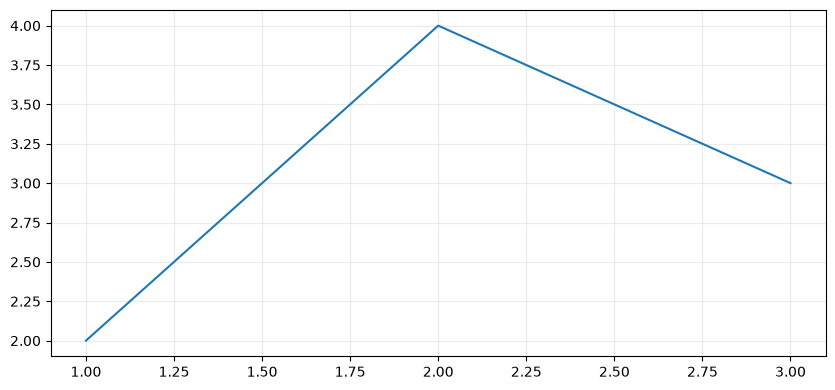

In [54]:
plt.plot([1, 2, 3], [2, 4, 3]);

Read it from the inside out:

- the first list supplies x positions;
- the second list supplies y positions;
- `plt.plot` connects the points; and
- the semicolon suppresses Jupyter's technical object representation.

## 7. Plot level 1: a reproducible random line

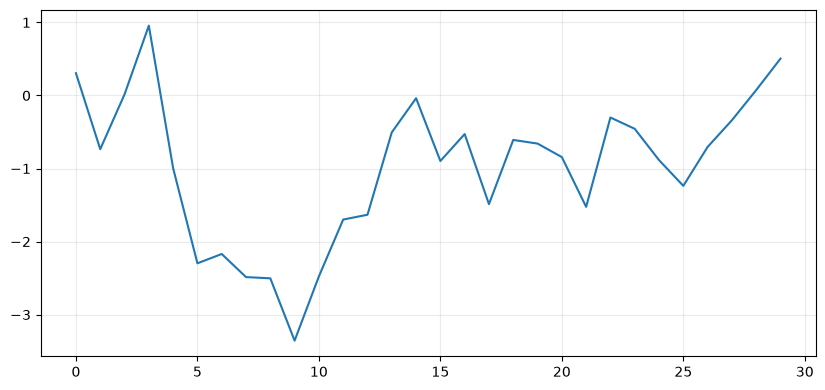

In [86]:
rng = np.random.default_rng(seed=42)
random_line = rng.normal(size=30).cumsum()

plt.plot(random_line);

## 8. Plot level 2: name the figure and axes

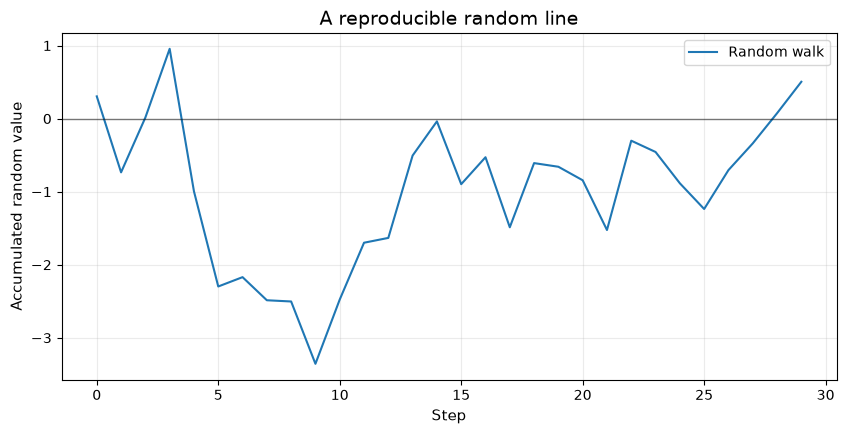

In [90]:
fig, ax = plt.subplots()

ax.plot(random_line,
        label="Random walk",)

ax.set_title("A reproducible random line")
ax.set_xlabel("Step")
ax.set_ylabel("Accumulated random value")
ax.axhline(0, color="black", linewidth=1, alpha=0.5)
ax.legend()
ax.grid(True, alpha=0.25)


plt.show()

## 9. Plot level 3: manipulate the plot

Change one argument at a time and rerun.

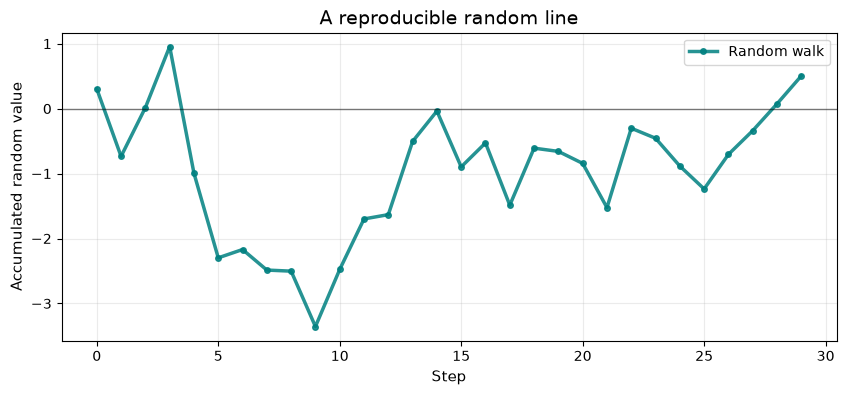

In [91]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    random_line,
    color="teal",
    linewidth=2.5,
    linestyle="-",
    marker="o",
    markersize=4,
    alpha=0.85,
    label="Random walk",
)

ax.set_title("A reproducible random line")
ax.set_xlabel("Step")
ax.set_ylabel("Accumulated random value")
ax.axhline(0, color="black", linewidth=1, alpha=0.5)
ax.legend()
ax.grid(True, alpha=0.25)

plt.show()

### Syntax experiment

Change only one item per run:

1. change the colour;
2. try `linestyle="--"`;
3. remove the marker;
4. change the figure size;
5. add `ax.set_ylim(-10, 10)`; and
6. identify which line changes data and which lines change only presentation.

## 10. Plot level 4: first real pollutant line

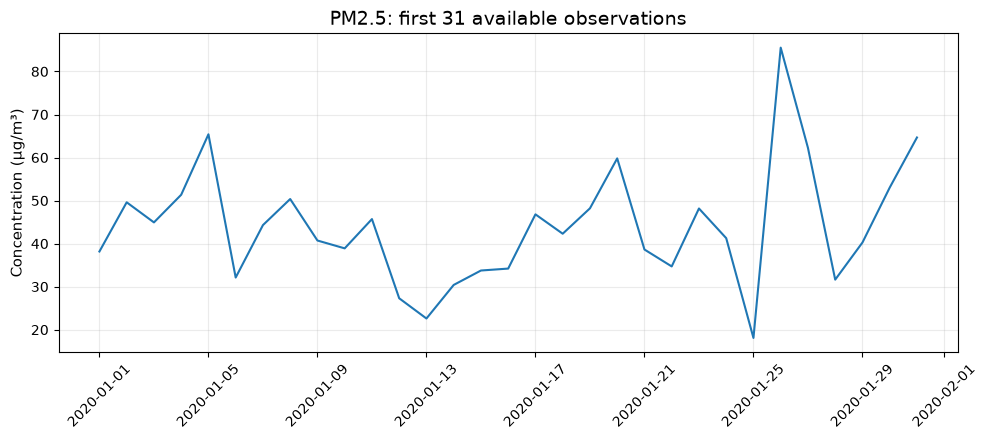

In [92]:
sample = air_quality.head(31)

plt.plot(sample["Date"], sample["PM2.5"])
plt.xticks(rotation=45)
plt.title("PM2.5: first 31 available observations")
plt.ylabel("Concentration (µg/m³)")
plt.tight_layout()
plt.show()

## 11. Plot level 5: reusable styling

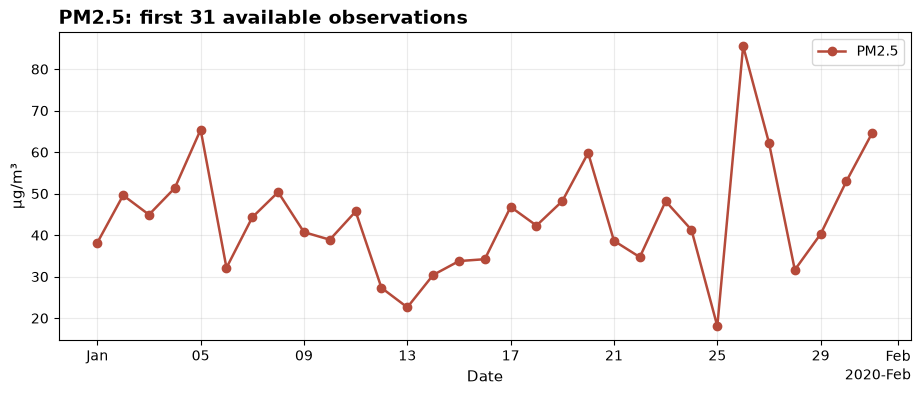

In [93]:
def style_time_axis(ax, title, ylabel="Concentration"):
    """Apply consistent labels and compact date formatting."""
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel(ylabel)
    locator = mdates.AutoDateLocator()
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(
        mdates.ConciseDateFormatter(locator)
    )
    ax.grid(True, alpha=0.25)
    return ax

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(
    sample["Date"],
    sample["PM2.5"],
    color="#B54A3A",
    marker="o",
    linewidth=1.8,
    label="PM2.5",
)
style_time_axis(
    ax,
    "PM2.5: first 31 available observations",
    "µg/m³",
)
ax.legend()
plt.show()

## 12. Plot level 6: choose any pollutant

The function separates data selection from plot styling.

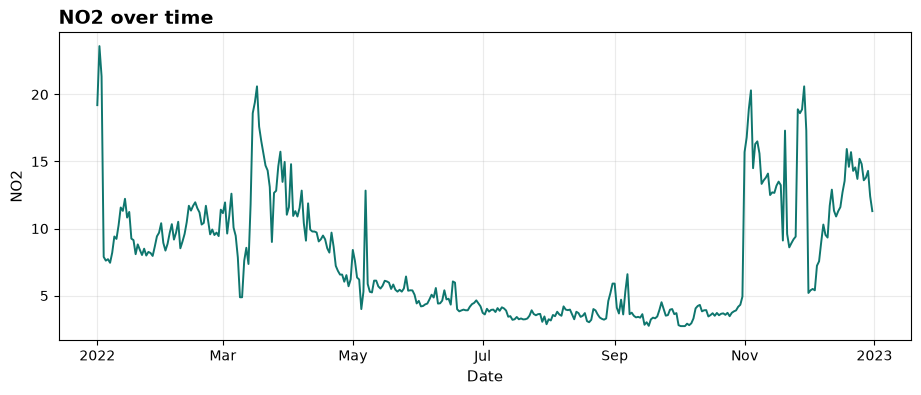

In [94]:
def plot_pollutant(
    data,
    pollutant,
    start=None,
    end=None,
    color="teal",
):
    """Plot one column over an optional date range."""
    view = data.copy()

    if start is not None:
        view = view.loc[view["Date"] >= pd.Timestamp(start)]
    if end is not None:
        view = view.loc[view["Date"] <= pd.Timestamp(end)]

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(
        view["Date"],
        view[pollutant],
        color=color,
        linewidth=1.4,
    )
    style_time_axis(
        ax,
        f"{pollutant} over time",
        pollutant,
    )
    plt.show()
    return view

selected_view = plot_pollutant(
    air_quality,
    pollutant="NO2",
    start="2022-01-01",
    end="2022-12-31",
    color="#0F766E",
)

## 13. Plot level 7: several pollutants on one axes

This is simple code but can be difficult to interpret when variables have different ranges.

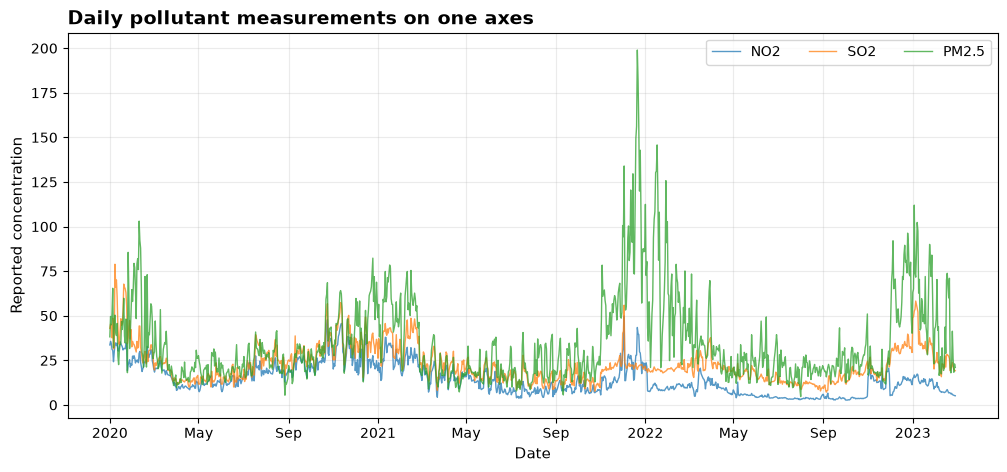

In [61]:
pollutants = ["NO2", "SO2", "PM2.5"]

fig, ax = plt.subplots(figsize=(12, 5))

for pollutant in pollutants:
    ax.plot(
        air_quality["Date"],
        air_quality[pollutant],
        linewidth=1,
        alpha=0.75,
        label=pollutant,
    )

style_time_axis(
    ax,
    "Daily pollutant measurements on one axes",
    "Reported concentration",
)
ax.legend(ncol=3)
plt.show()

## 14. Plot level 8: small multiples

Separate axes reduce overlap and permit separate scales.

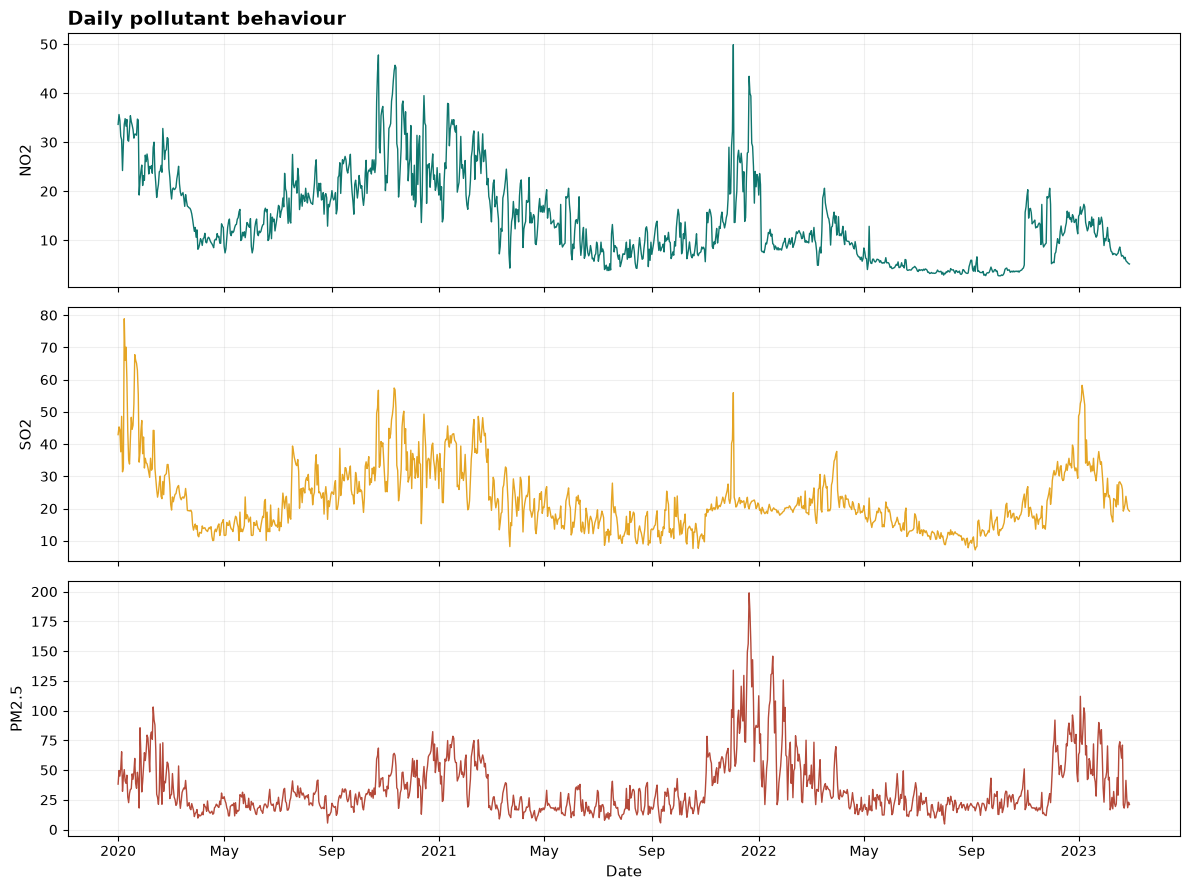

In [62]:
colors = {
    "NO2": "#0F766E",
    "SO2": "#E5A524",
    "PM2.5": "#B54A3A",
}

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 9),
    sharex=True,
)

for ax, pollutant in zip(axes, pollutants):
    ax.plot(
        air_quality["Date"],
        air_quality[pollutant],
        color=colors[pollutant],
        linewidth=1,
    )
    ax.set_ylabel(pollutant)
    ax.grid(True, alpha=0.2)

axes[0].set_title(
    "Daily pollutant behaviour",
    loc="left",
    fontweight="bold",
)
axes[-1].set_xlabel("Date")
locator = mdates.AutoDateLocator()
axes[-1].xaxis.set_major_locator(locator)
axes[-1].xaxis.set_major_formatter(
    mdates.ConciseDateFormatter(locator)
)

plt.tight_layout()
plt.show()

## 15. Plot level 9: rolling average

A rolling mean reduces day-to-day variation. It is a data transformation, so the window must be stated.

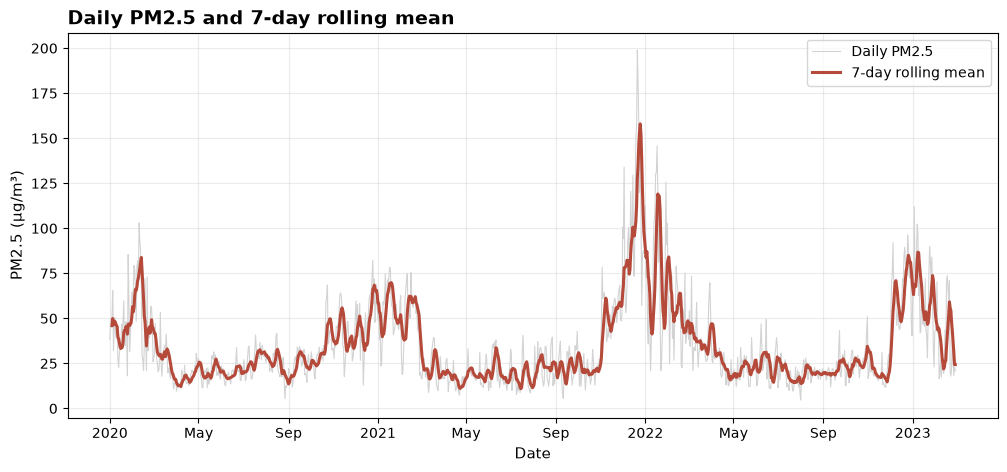

In [105]:
# window=7

plot_data = air_quality[
    ["Date", "PM2.5"]
].dropna().copy()

plot_data["PM2.5_7_day_mean"] = (
    plot_data["PM2.5"]
    .rolling(window=7, min_periods=4)
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    plot_data["Date"],
    plot_data["PM2.5"],
    color="lightgray",
    linewidth=0.8,
    label="Daily PM2.5",
)
ax.plot(
    plot_data["Date"],
    plot_data["PM2.5_7_day_mean"],
    color="#B54A3A",
    linewidth=2.2,
    label="7-day rolling mean",
)

style_time_axis(
    ax,
    "Daily PM2.5 and 7-day rolling mean",
    "PM2.5 (µg/m³)",
)
ax.legend()
plt.show()

## 16. Plot level 10: aggregate before plotting

This answers a monthly question rather than a daily question.

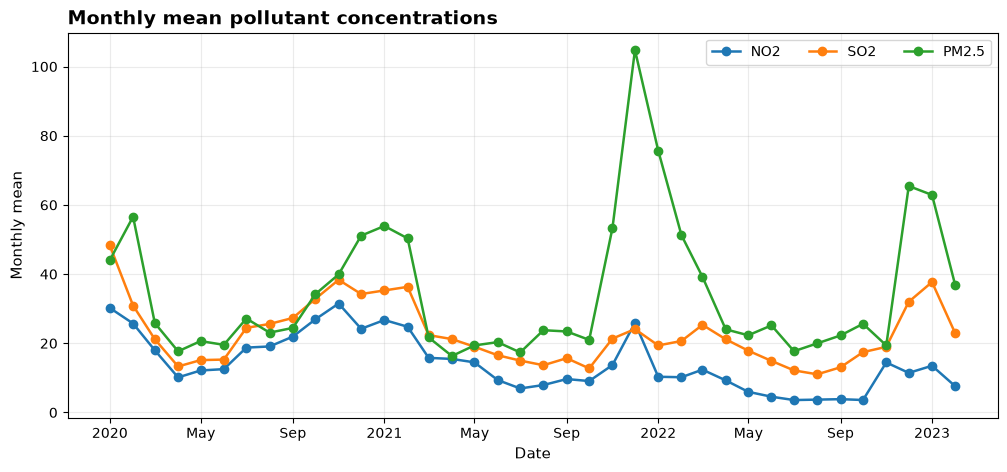

In [106]:
monthly = (
    air_quality
    .dropna(subset=["Date"])
    .set_index("Date")[pollutants]
    .resample("MS")
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 5))

for pollutant in pollutants:
    ax.plot(
        monthly.index,
        monthly[pollutant],
        marker="o",
        linewidth=1.8,
        label=pollutant,
    )

style_time_axis(
    ax,
    "Monthly mean pollutant concentrations",
    "Monthly mean",
)
ax.legend(ncol=3)
plt.show()

## 17. Plot level 11: calendar-month behaviour

Grouping by calendar month can reveal seasonality, but it hides year-to-year differences.

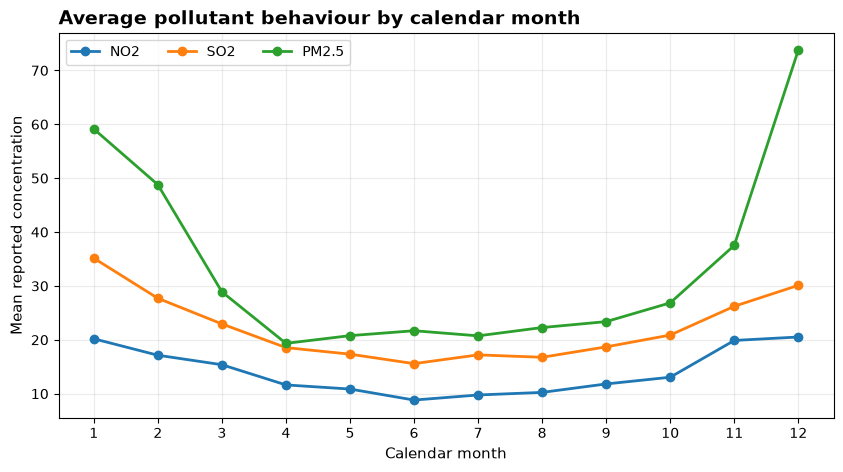

In [107]:
seasonal = (
    air_quality
    .assign(month=air_quality["Date"].dt.month)
    .groupby("month")[pollutants]
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 5))

for pollutant in pollutants:
    ax.plot(
        seasonal.index,
        seasonal[pollutant],
        marker="o",
        linewidth=2,
        label=pollutant,
    )

ax.set_title(
    "Average pollutant behaviour by calendar month",
    loc="left",
    fontweight="bold",
)
ax.set_xlabel("Calendar month")
ax.set_ylabel("Mean reported concentration")
ax.set_xticks(range(1, 13))
ax.legend(ncol=3)
plt.show()

## 18. Plot level 12: distribution

A histogram answers a different question from a time-series line.

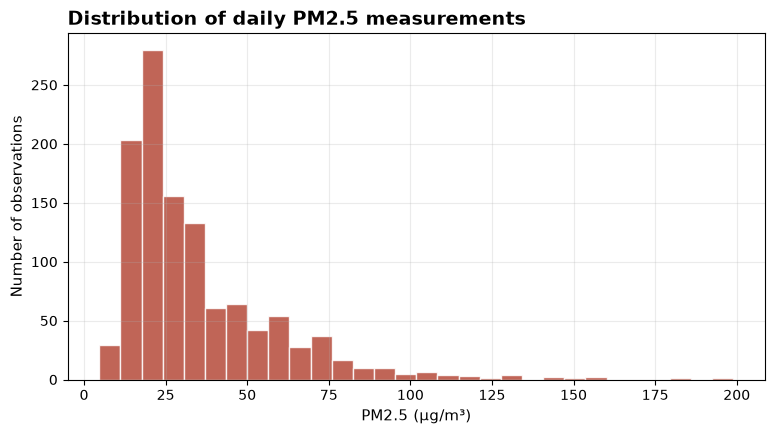

In [108]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.hist(
    air_quality["PM2.5"].dropna(),
    bins=30,
    color="#B54A3A",
    edgecolor="white",
    alpha=0.85,
)

ax.set_title(
    "Distribution of daily PM2.5 measurements",
    loc="left",
    fontweight="bold",
)
ax.set_xlabel("PM2.5 (µg/m³)")
ax.set_ylabel("Number of observations")

plt.show()

## 19. Plot level 13: relationship

A scatter plot may show association. It does not establish causation.

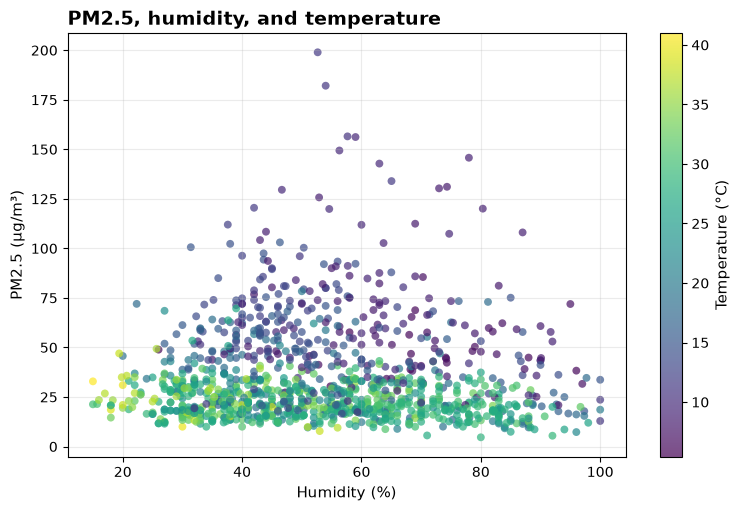

In [109]:
scatter_data = air_quality[
    ["Humidity", "Temperature", "PM2.5"]
].dropna()

fig, ax = plt.subplots(figsize=(9, 5.5))

points = ax.scatter(
    scatter_data["Humidity"],
    scatter_data["PM2.5"],
    c=scatter_data["Temperature"],
    cmap="viridis",
    s=32,
    alpha=0.7,
    edgecolor="none",
)

ax.set_title(
    "PM2.5, humidity, and temperature",
    loc="left",
    fontweight="bold",
)
ax.set_xlabel("Humidity (%)")
ax.set_ylabel("PM2.5 (µg/m³)")

colorbar = fig.colorbar(points, ax=ax)
colorbar.set_label("Temperature (°C)")

plt.show()

## 20. Plot level 14: correlation heatmap

This uses Matplotlib directly, so no extra plotting package is required.

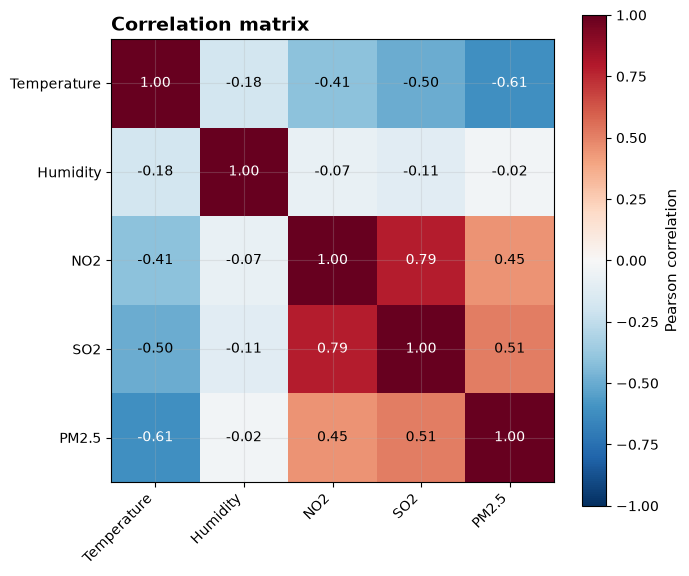

In [110]:
numeric_columns = [
    "Temperature",
    "Humidity",
    "NO2",
    "SO2",
    "PM2.5",
]

correlations = air_quality[numeric_columns].corr()

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(
    correlations,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
)

ax.set_xticks(
    range(len(numeric_columns)),
    numeric_columns,
    rotation=45,
    ha="right",
)
ax.set_yticks(
    range(len(numeric_columns)),
    numeric_columns,
)
ax.set_title(
    "Correlation matrix",
    loc="left",
    fontweight="bold",
)

for row in range(len(numeric_columns)):
    for column in range(len(numeric_columns)):
        value = correlations.iloc[row, column]
        ax.text(
            column,
            row,
            f"{value:.2f}",
            ha="center",
            va="center",
            color=(
                "white"
                if abs(value) > 0.55
                else "black"
            ),
        )

fig.colorbar(image, ax=ax, label="Pearson correlation")
plt.tight_layout()
plt.show()

## 21. Plot level 15: compact analytical dashboard

The code is longer because it coordinates four axes and several transformations. Complexity is justified only when each panel answers a useful question.

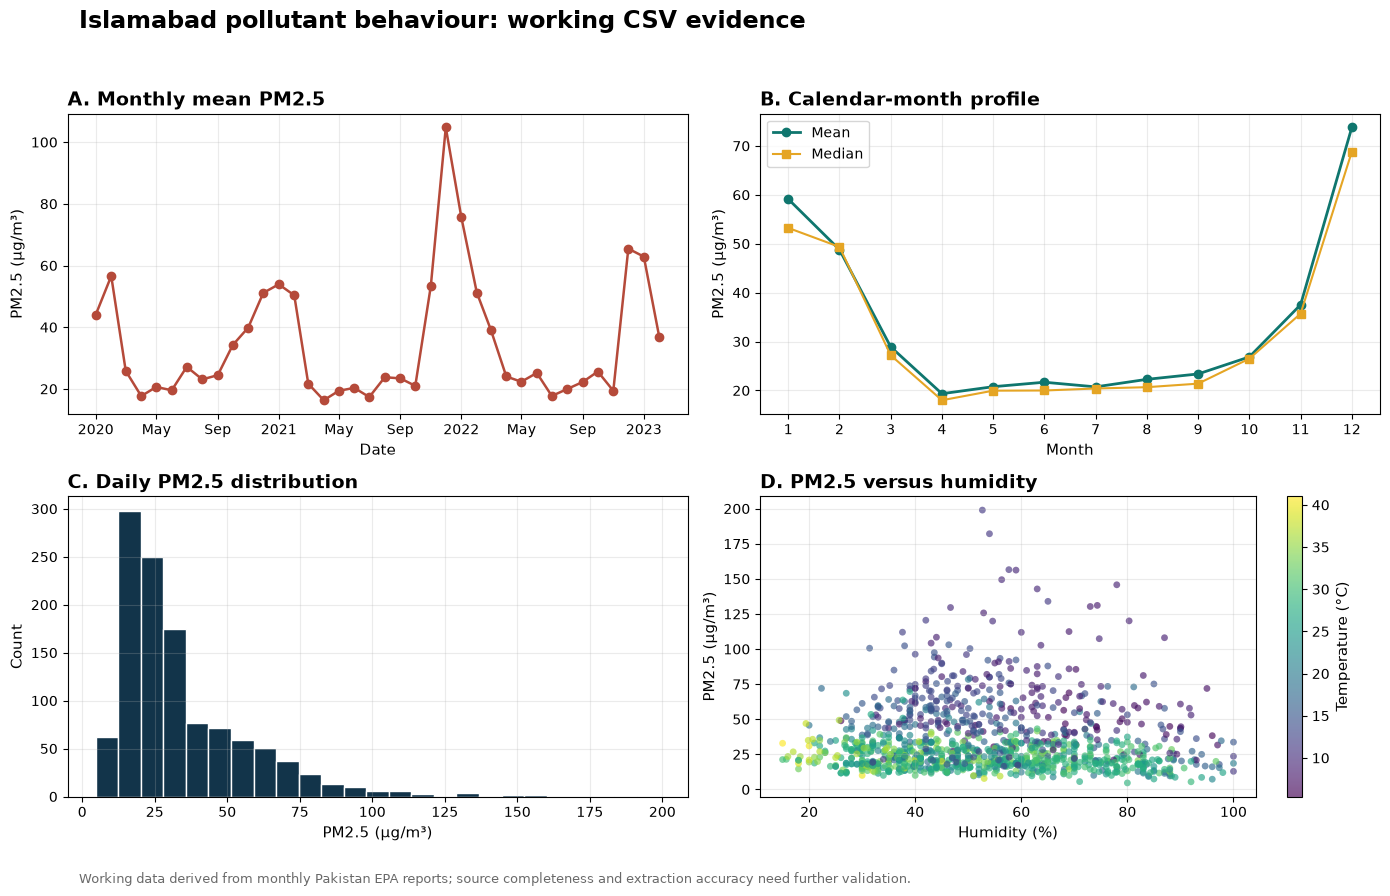

In [111]:
def build_pollutant_dashboard(data):
    """Build a four-panel summary without modifying the input."""
    clean = data.dropna(subset=["Date"]).copy()

    monthly_pm25 = (
        clean.set_index("Date")["PM2.5"]
        .resample("MS")
        .mean()
    )
    month_profile = (
        clean.assign(month=clean["Date"].dt.month)
        .groupby("month")["PM2.5"]
        .agg(["mean", "median"])
    )

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    ax_time, ax_season, ax_hist, ax_scatter = axes.ravel()

    ax_time.plot(
        monthly_pm25.index,
        monthly_pm25.values,
        color="#B54A3A",
        marker="o",
        linewidth=1.8,
    )
    style_time_axis(
        ax_time,
        "A. Monthly mean PM2.5",
        "PM2.5 (µg/m³)",
    )

    ax_season.plot(
        month_profile.index,
        month_profile["mean"],
        marker="o",
        color="#0F766E",
        linewidth=2,
        label="Mean",
    )
    ax_season.plot(
        month_profile.index,
        month_profile["median"],
        marker="s",
        color="#E5A524",
        linewidth=1.5,
        label="Median",
    )
    ax_season.set_title(
        "B. Calendar-month profile",
        loc="left",
        fontweight="bold",
    )
    ax_season.set_xlabel("Month")
    ax_season.set_ylabel("PM2.5 (µg/m³)")
    ax_season.set_xticks(range(1, 13))
    ax_season.legend()

    ax_hist.hist(
        clean["PM2.5"].dropna(),
        bins=25,
        color="#12344A",
        edgecolor="white",
    )
    ax_hist.set_title(
        "C. Daily PM2.5 distribution",
        loc="left",
        fontweight="bold",
    )
    ax_hist.set_xlabel("PM2.5 (µg/m³)")
    ax_hist.set_ylabel("Count")

    relationship = clean[
        ["Humidity", "PM2.5", "Temperature"]
    ].dropna()
    points = ax_scatter.scatter(
        relationship["Humidity"],
        relationship["PM2.5"],
        c=relationship["Temperature"],
        cmap="viridis",
        s=24,
        alpha=0.65,
        edgecolor="none",
    )
    ax_scatter.set_title(
        "D. PM2.5 versus humidity",
        loc="left",
        fontweight="bold",
    )
    ax_scatter.set_xlabel("Humidity (%)")
    ax_scatter.set_ylabel("PM2.5 (µg/m³)")
    fig.colorbar(
        points,
        ax=ax_scatter,
        label="Temperature (°C)",
    )

    fig.suptitle(
        "Islamabad pollutant behaviour: working CSV evidence",
        fontsize=17,
        fontweight="bold",
        x=0.06,
        ha="left",
    )
    fig.text(
        0.06,
        0.01,
        "Working data derived from monthly Pakistan EPA reports; "
        "source completeness and extraction accuracy need further validation.",
        fontsize=9,
        color="dimgray",
    )
    fig.tight_layout(rect=(0, 0.04, 1, 0.95))
    return fig, axes

dashboard_figure, dashboard_axes = build_pollutant_dashboard(
    air_quality
)
plt.show()

## 22. Save a figure deliberately

Saving is isolated so rerunning analysis does not unexpectedly overwrite an output.

In [112]:
SAVE_FIGURE = False
OUTPUT_DIR = Path.cwd() / "generated_outputs"
OUTPUT_PATH = (
    OUTPUT_DIR / "islamabad_pollutant_dashboard.png"
)

if SAVE_FIGURE:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    dashboard_figure.savefig(
        OUTPUT_PATH,
        dpi=200,
        bbox_inches="tight",
    )
    print("Saved:", OUTPUT_PATH.resolve())
else:
    print(
        "Figure not saved. "
        "Set SAVE_FIGURE = True to write the PNG."
    )

Figure not saved. Set SAVE_FIGURE = True to write the PNG.


## 23. Plot-manipulation practice

Choose one earlier plot and make four changes:

1. one **data-selection** change;
2. one **geometry** change such as line, marker, or histogram bins;
3. one **annotation** change such as title, label, legend, or reference line; and
4. one **layout** change such as size, limits, or subplots.

Then explain which change altered the evidence and which changed only its presentation.

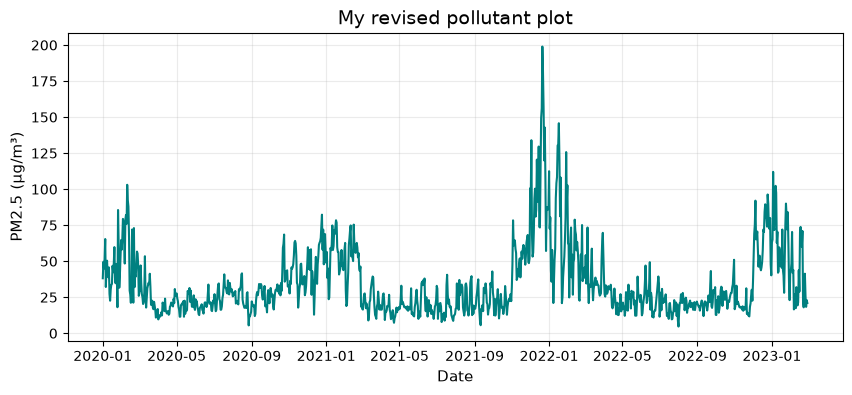

In [113]:
# Student workspace

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    air_quality["Date"],
    air_quality["PM2.5"],
    color="teal",
)

ax.set_title("My revised pollutant plot")
ax.set_xlabel("Date")
ax.set_ylabel("PM2.5 (µg/m³)")

plt.show()

# Part D: Provisional AQI and external weather data

## 24. The scanned report after OCR

With the Windows Tesseract executable configured, OCR returns text from the December 2022 scan. The result still corrupts dates, decimals, pollutant labels, and column boundaries. It is useful for locating possible content, but it is not a trustworthy table.

**Teaching conclusion:** manual transcription is an appropriate tool for this scan when each entered row is checked against the image. The failure is semantic, not merely technical: OCR produced characters but did not preserve the table reliably.

## 25. AQI terminology before calculation

The combined 2020–2023 CSV files contain pollutant **concentrations**, not AQI values. A complete overall AQI also requires a documented breakpoint system and the required pollutants.

For this exercise we calculate a **provisional PM2.5-based AQI** using the breakpoint pattern visible in the July 2026 Pakistan EPA report. It should not be presented as a verified overall AQI. The comparison cell checks the calculation against the AQI values printed in that report.

In [114]:
import re

def parse_july_2026_aqi(pdf_path):
    """Parse searchable concentration, AQI, and category rows."""
    import pdfplumber

    lines = []
    with pdfplumber.open(pdf_path) as document:
        for page in document.pages:
            lines.extend((page.extract_text() or "").splitlines())

    pattern = re.compile(
        r"^(\d{1,2}-7-2026)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)$"
    )
    rows = []

    for index, line in enumerate(lines):
        match = pattern.match(line)
        if not match:
            continue

        aqi_values = [int(value) for value in lines[index + 1].split()]
        categories = re.findall(r"\(([^)]+)\)", lines[index + 3])
        if lines[index + 2] != "AQI" or len(aqi_values) != 4 or len(categories) != 4:
            raise ValueError(f"Unexpected AQI block after {line}")

        rows.append({
            "Date": pd.to_datetime(match.group(1), dayfirst=True),
            "SO2": float(match.group(2)),
            "CO": float(match.group(3)),
            "NO2": float(match.group(4)),
            "PM2.5": float(match.group(5)),
            "SO2_AQI": aqi_values[0],
            "CO_AQI": aqi_values[1],
            "NO2_AQI": aqi_values[2],
            "PM2.5_AQI": aqi_values[3],
            "SO2_category": categories[0],
            "CO_category": categories[1],
            "NO2_category": categories[2],
            "PM2.5_category": categories[3],
        })

    parsed = pd.DataFrame(rows).sort_values("Date").reset_index(drop=True)
    if len(parsed) != 31:
        raise ValueError(f"Expected 31 days, found {len(parsed)}")
    return parsed

latest_aqi_pdf = next(
    path for path in PDF_PATHS
    if path.name == "July, 2026 Air Quality Data with AQI (1).pdf"
)
july_2026_aqi = parse_july_2026_aqi(latest_aqi_pdf)
july_2026_aqi.head()

,Date,SO2,CO,NO2,PM2.5,SO2_AQI,CO_AQI,NO2_AQI,PM2.5_AQI,SO2_category,CO_category,NO2_category,PM2.5_category
0,2026-07-01,14.4,356.9,3.5,53.7,20,4,3,146,Good,Good,Good,UFSG
1,2026-07-02,11.2,444.1,5.1,26.4,16,5,5,81,Good,Good,Good,Moderate
2,2026-07-03,11.2,499.2,5.4,38.6,16,6,5,108,Good,Good,Good,UFSG
3,2026-07-04,11.3,961.1,8.0,32.7,16,11,7,94,Good,Good,Good,Moderate
4,2026-07-05,11.3,829.1,7.2,46.0,16,9,7,126,Good,Good,Good,UFSG


In [115]:
PM25_BREAKPOINTS = pd.DataFrame([
    [0.0, 12.0, 0, 50, "Good"],
    [12.1, 35.4, 51, 100, "Moderate"],
    [35.5, 55.4, 101, 150, "UFSG"],
    [55.5, 150.4, 151, 200, "Unhealthy"],
    [150.5, 250.4, 201, 300, "Very Unhealthy"],
    [250.5, 350.4, 301, 400, "Hazardous"],
    [350.5, 500.4, 401, 500, "Hazardous"],
], columns=[
    "concentration_low", "concentration_high",
    "aqi_low", "aqi_high", "category",
])

def provisional_pm25_aqi(concentration):
    """Calculate a PM2.5-based AQI for teaching and validation."""
    if pd.isna(concentration):
        return np.nan

    value = np.floor(float(concentration) * 10) / 10
    for row in PM25_BREAKPOINTS.itertuples(index=False):
        if row.concentration_low <= value <= row.concentration_high:
            raw = (
                (row.aqi_high - row.aqi_low)
                / (row.concentration_high - row.concentration_low)
                * (value - row.concentration_low)
                + row.aqi_low
            )
            return int(np.floor(raw))
    return np.nan

def aqi_category(aqi):
    if pd.isna(aqi):
        return "Missing"
    if aqi <= 50:
        return "Good"
    if aqi <= 100:
        return "Moderate"
    if aqi <= 150:
        return "UFSG"
    if aqi <= 200:
        return "Unhealthy"
    if aqi <= 300:
        return "Very Unhealthy"
    return "Hazardous"

PM25_BREAKPOINTS

,concentration_low,concentration_high,aqi_low,aqi_high,category
0,0.0,12.0,0,50,Good
1,12.1,35.4,51,100,Moderate
2,35.5,55.4,101,150,UFSG
3,55.5,150.4,151,200,Unhealthy
4,150.5,250.4,201,300,Very Unhealthy
5,250.5,350.4,301,400,Hazardous
6,350.5,500.4,401,500,Hazardous


In [116]:
aqi_validation = july_2026_aqi[["Date", "PM2.5", "PM2.5_AQI"]].copy()
aqi_validation["calculated_AQI"] = aqi_validation["PM2.5"].map(
    provisional_pm25_aqi
)
aqi_validation["difference"] = (
    aqi_validation["calculated_AQI"]
    - aqi_validation["PM2.5_AQI"]
)

display(aqi_validation.head(10))
print(
    "Days within one AQI point:",
    int(aqi_validation["difference"].abs().le(1).sum()),
    "of",
    len(aqi_validation),
)
print(
    "The one-point differences are consistent with hidden precision or rounding; "
    "the calculation remains provisional."
)

,Date,PM2.5,PM2.5_AQI,calculated_AQI,difference
0,2026-07-01,53.7,146,145,-1
1,2026-07-02,26.4,81,81,0
2,2026-07-03,38.6,108,108,0
3,2026-07-04,32.7,94,94,0
4,2026-07-05,46.0,126,126,0
5,2026-07-06,47.9,131,131,0
6,2026-07-07,32.3,93,93,0
7,2026-07-08,39.0,109,109,0
8,2026-07-09,27.0,82,82,0
9,2026-07-10,37.6,105,106,1


Days within one AQI point: 31 of 31
The one-point differences are consistent with hidden precision or rounding; the calculation remains provisional.


## 26. Monthly PM2.5-based AQI, 2020–2022

For each year and month, calculate the mean daily provisional AQI. The bar height is the mean of the three yearly monthly means. The error bar is their sample standard deviation, so each month has **n = 3 yearly means**.

The partial 2023 file is excluded because it does not contain all twelve months. Bar colours indicate the category of the monthly mean, not the number of good or bad days.

In [117]:
analysis_3y = air_quality.loc[
    air_quality["Date"].dt.year.isin([2020, 2021, 2022])
].copy()
analysis_3y["PM2.5_AQI_provisional"] = analysis_3y["PM2.5"].map(
    provisional_pm25_aqi
)
analysis_3y["year"] = analysis_3y["Date"].dt.year
analysis_3y["month"] = analysis_3y["Date"].dt.month

year_month_aqi = (
    analysis_3y
    .groupby(["year", "month"])["PM2.5_AQI_provisional"]
    .mean()
    .unstack("year")
)
monthly_aqi_summary = pd.DataFrame({
    "mean": year_month_aqi.mean(axis=1),
    "sd": year_month_aqi.std(axis=1, ddof=1),
})
monthly_aqi_summary["category"] = monthly_aqi_summary["mean"].map(
    aqi_category
)
monthly_aqi_summary.round(1)

,mean,sd,category
month,,,
1,134.9,15.5,UFSG
2,131.7,1.3,UFSG
3,85.9,19.3,Moderate
4,65.2,9.2,Moderate
5,68.7,3.2,Moderate
6,70.6,6.6,Moderate
7,67.9,12.5,Moderate
8,71.7,4.6,Moderate
9,74.0,2.4,Moderate


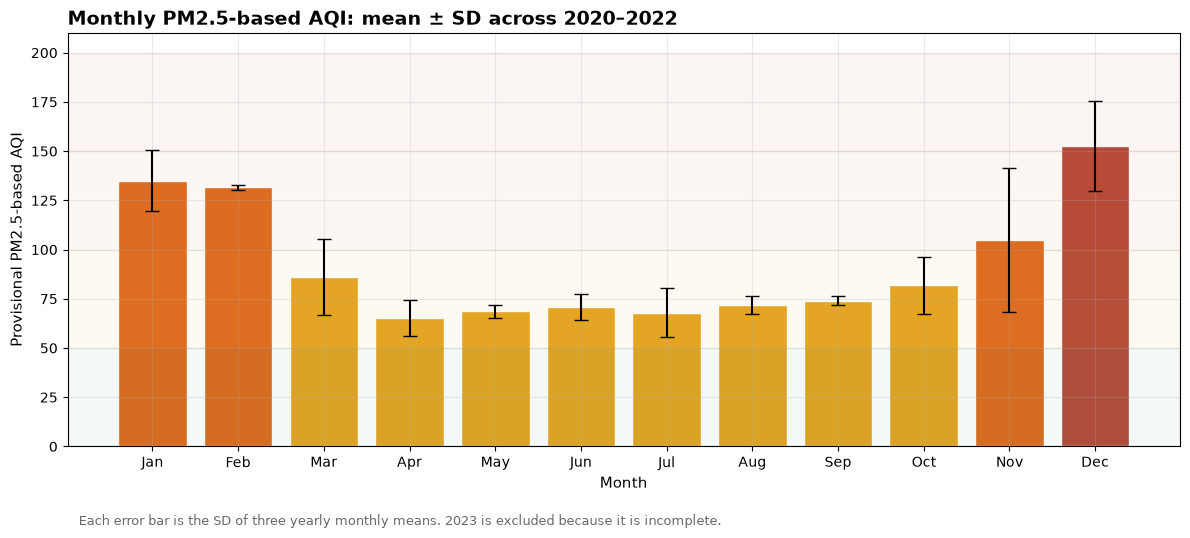

In [118]:
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
category_colors = {
    "Good": "#2F855A",
    "Moderate": "#E5A524",
    "UFSG": "#DD6B20",
    "Unhealthy": "#B54A3A",
    "Very Unhealthy": "#805AD5",
    "Hazardous": "#6B2737",
}
bar_colors = [
    category_colors[category]
    for category in monthly_aqi_summary["category"]
]

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.bar(
    month_labels,
    monthly_aqi_summary["mean"],
    yerr=monthly_aqi_summary["sd"],
    capsize=5,
    color=bar_colors,
    edgecolor="white",
)
ax.axhspan(0, 50, color=category_colors["Good"], alpha=0.05)
ax.axhspan(50, 100, color=category_colors["Moderate"], alpha=0.05)
ax.axhspan(100, 150, color=category_colors["UFSG"], alpha=0.05)
ax.axhspan(150, 200, color=category_colors["Unhealthy"], alpha=0.05)
ax.set_title(
    "Monthly PM2.5-based AQI: mean ± SD across 2020–2022",
    loc="left",
    fontweight="bold",
)
ax.set_xlabel("Month")
ax.set_ylabel("Provisional PM2.5-based AQI")
ax.text(
    0.01, -0.19,
    "Each error bar is the SD of three yearly monthly means. 2023 is excluded because it is incomplete.",
    transform=ax.transAxes, fontsize=9, color="dimgray",
)
plt.tight_layout()
plt.show()

## 27. Question: do temperature and humidity relate to PM2.5-based AQI?

The monthly chart suggests a seasonal pattern, but it does not identify its cause. Scatter plots let us ask whether temperature and humidity have linear associations with the provisional AQI.

Association does not establish causation. Temperature, humidity, emissions, wind, rain, boundary-layer height, and season may change together.

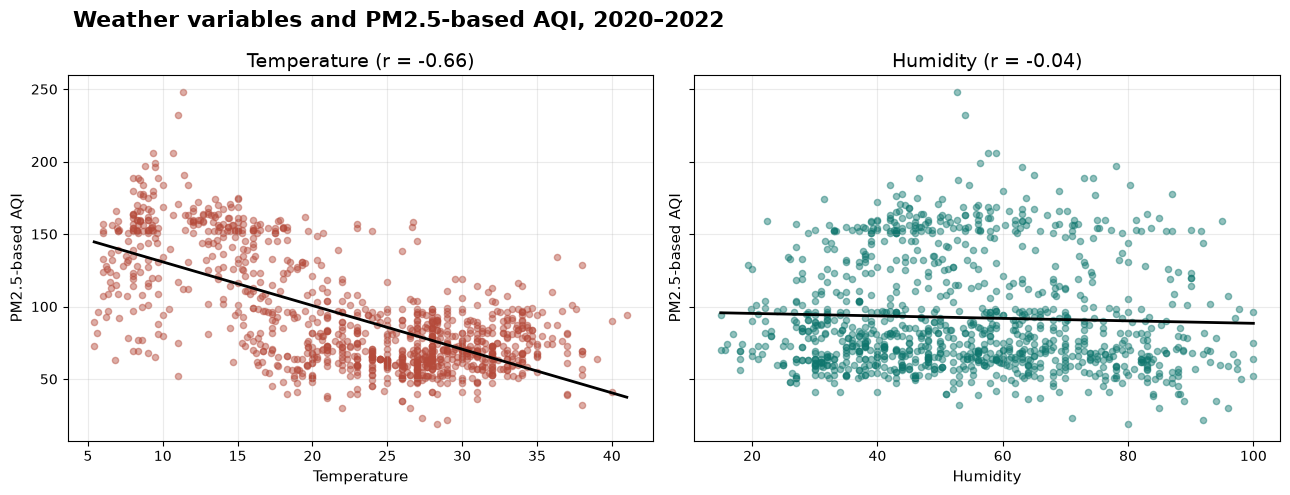

Temperature correlation: -0.662
Humidity correlation: -0.042


In [119]:
def scatter_with_trend(ax, data, x, y, color):
    view = data[[x, y]].dropna()
    ax.scatter(view[x], view[y], s=20, alpha=0.45, color=color)
    slope, intercept = np.polyfit(view[x], view[y], 1)
    x_line = np.linspace(view[x].min(), view[x].max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color="black", linewidth=2)
    correlation = view[x].corr(view[y])
    ax.set_title(f"{x} (r = {correlation:.2f})")
    ax.set_xlabel(x)
    ax.set_ylabel("PM2.5-based AQI")
    return correlation

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
r_temperature = scatter_with_trend(
    axes[0], analysis_3y, "Temperature", "PM2.5_AQI_provisional", "#B54A3A"
)
r_humidity = scatter_with_trend(
    axes[1], analysis_3y, "Humidity", "PM2.5_AQI_provisional", "#0F766E"
)
fig.suptitle(
    "Weather variables and PM2.5-based AQI, 2020–2022",
    fontsize=16, fontweight="bold", x=0.06, ha="left",
)
fig.tight_layout()
plt.show()

print(f"Temperature correlation: {r_temperature:.3f}")
print(f"Humidity correlation: {r_humidity:.3f}")

### Interpretation prompt

In the 2020–2022 working data, temperature has a substantial negative correlation with provisional PM2.5-based AQI, while humidity has little overall linear correlation. This pattern does not prove that changing temperature causes AQI to change. Season and unmeasured meteorology may explain part of the association.

Now inspect the July 2026 AQI PDF: it provides pollutant concentrations and AQI rows but no temperature or humidity. That absence does **not** mean weather has no relationship with pollution. It means the report cannot answer the weather question by itself. We need a second data source and a documented join.

## 28. Meteostat hourly weather data

The nearest Meteostat station returned for the selected Islamabad point is **Islamabad Airport (41571)**. Its location is about 8.9 km from the selected point, so the weather and air-quality measurements do not come from the same instrument or exact location.

The query uses the `Asia/Karachi` timezone. It retrieves hourly temperature and relative humidity, then calculates daily means only after counting the available hours. The July 2026 response identifies the provider as `dwd_mosmix`, which is modeled weather information. Preserve this disclosure when interpreting the merge.

In [120]:
from datetime import datetime

WEATHER_STATION_ID = "41571"
WEATHER_STATION_NAME = "Islamabad Airport"
WEATHER_TIMEZONE = "Asia/Karachi"

def fetch_meteostat_daily_weather():
    """Fetch hourly weather and aggregate it by local calendar day."""
    import meteostat as ms

    series = ms.hourly(
        WEATHER_STATION_ID,
        datetime(2026, 7, 1),
        datetime(2026, 7, 31, 23, 59),
        timezone=WEATHER_TIMEZONE,
        parameters=[ms.Parameter.TEMP, ms.Parameter.RHUM],
    )
    hourly = series.fetch(sources=True, location=True)
    if hourly is None or hourly.empty:
        raise RuntimeError("Meteostat returned no hourly rows")

    hourly = hourly.copy()
    hourly["Date"] = hourly.index.tz_convert(WEATHER_TIMEZONE).date
    daily = (
        hourly.groupby("Date", as_index=False)
        .agg(
            Temperature=("temp", "mean"),
            Humidity=("rhum", "mean"),
            temperature_hour_count=("temp", "count"),
            humidity_hour_count=("rhum", "count"),
            temperature_source=("temp_source", lambda x: ";".join(sorted(set(x)))),
            humidity_source=("rhum_source", lambda x: ";".join(sorted(set(x)))),
        )
    )
    daily["Date"] = pd.to_datetime(daily["Date"])
    daily[["Temperature", "Humidity"]] = daily[["Temperature", "Humidity"]].round(2)
    return hourly, daily, series

weather_hourly, weather_daily, weather_series = fetch_meteostat_daily_weather()
print("Hourly rows:", len(weather_hourly))
print("Daily rows:", len(weather_daily))
display(weather_daily.head())

Hourly rows: 744
Daily rows: 31


,Date,Temperature,Humidity,temperature_hour_count,humidity_hour_count,temperature_source,humidity_source
0,2026-07-01,32.04,58.0,24,24,dwd_mosmix,dwd_mosmix
1,2026-07-02,29.46,65.17,24,24,dwd_mosmix,dwd_mosmix
2,2026-07-03,30.49,58.42,24,24,dwd_mosmix,dwd_mosmix
3,2026-07-04,32.76,50.38,24,24,dwd_mosmix,dwd_mosmix
4,2026-07-05,33.61,48.04,24,24,dwd_mosmix,dwd_mosmix


## 29. Merge by local calendar date

A matching date is necessary but not sufficient. The merge must also preserve the weather station, timezone, hourly coverage, provider, source URLs, and the fact that the measurements come from different locations.

In [121]:
def merge_air_quality_and_weather(aqi_data, daily_weather):
    merged = aqi_data.merge(
        daily_weather, on="Date", how="left", validate="one_to_one"
    )
    if merged[["Temperature", "Humidity"]].isna().any().any():
        raise ValueError("At least one AQI date has no weather match")

    merged["weather_station_id"] = WEATHER_STATION_ID
    merged["weather_station_name"] = WEATHER_STATION_NAME
    merged["weather_timezone"] = WEATHER_TIMEZONE
    merged["weather_attribution"] = weather_series.attribution
    merged["air_quality_source_file"] = latest_aqi_pdf.name
    merged["air_quality_source_url"] = (
        "https://environment.gov.pk/Detail/"
        "ZjU5NDM3YjItNTdiOS00NTk5LWExYzUtMjI2NzE5YjdlOGM5"
    )
    merged["weather_source_url"] = (
        "https://dev.meteostat.net/python/api/meteostat.hourly"
    )
    merged["merge_note"] = (
        "Air quality and weather come from different locations and instruments; "
        "joined by Asia/Karachi calendar date"
    )
    return merged

july_2026_merged = merge_air_quality_and_weather(
    july_2026_aqi, weather_daily
)

assert len(july_2026_merged) == 31
assert july_2026_merged["temperature_hour_count"].eq(24).all()
assert july_2026_merged["humidity_hour_count"].eq(24).all()

display(july_2026_merged.head())

,Date,SO2,CO,NO2,PM2.5,SO2_AQI,CO_AQI,NO2_AQI,PM2.5_AQI,SO2_category,...,temperature_source,humidity_source,weather_station_id,weather_station_name,weather_timezone,weather_attribution,air_quality_source_file,air_quality_source_url,weather_source_url,merge_note
0,2026-07-01,14.4,356.9,3.5,53.7,20,4,3,146,Good,...,dwd_mosmix,dwd_mosmix,41571,Islamabad Airport,Asia/Karachi,"Meteostat, Deutscher Wetterdienst","July, 2026 Air Quality Data with AQI (1).pdf",https://environment.gov.pk/Detail/ZjU5NDM3YjIt...,https://dev.meteostat.net/python/api/meteostat...,Air quality and weather come from different lo...
1,2026-07-02,11.2,444.1,5.1,26.4,16,5,5,81,Good,...,dwd_mosmix,dwd_mosmix,41571,Islamabad Airport,Asia/Karachi,"Meteostat, Deutscher Wetterdienst","July, 2026 Air Quality Data with AQI (1).pdf",https://environment.gov.pk/Detail/ZjU5NDM3YjIt...,https://dev.meteostat.net/python/api/meteostat...,Air quality and weather come from different lo...
2,2026-07-03,11.2,499.2,5.4,38.6,16,6,5,108,Good,...,dwd_mosmix,dwd_mosmix,41571,Islamabad Airport,Asia/Karachi,"Meteostat, Deutscher Wetterdienst","July, 2026 Air Quality Data with AQI (1).pdf",https://environment.gov.pk/Detail/ZjU5NDM3YjIt...,https://dev.meteostat.net/python/api/meteostat...,Air quality and weather come from different lo...
3,2026-07-04,11.3,961.1,8.0,32.7,16,11,7,94,Good,...,dwd_mosmix,dwd_mosmix,41571,Islamabad Airport,Asia/Karachi,"Meteostat, Deutscher Wetterdienst","July, 2026 Air Quality Data with AQI (1).pdf",https://environment.gov.pk/Detail/ZjU5NDM3YjIt...,https://dev.meteostat.net/python/api/meteostat...,Air quality and weather come from different lo...
4,2026-07-05,11.3,829.1,7.2,46.0,16,9,7,126,Good,...,dwd_mosmix,dwd_mosmix,41571,Islamabad Airport,Asia/Karachi,"Meteostat, Deutscher Wetterdienst","July, 2026 Air Quality Data with AQI (1).pdf",https://environment.gov.pk/Detail/ZjU5NDM3YjIt...,https://dev.meteostat.net/python/api/meteostat...,Air quality and weather come from different lo...


In [123]:
DERIVED_CSV_PATH = (
    DATA_DIR.parent / "outputs"
    / "Islamabad_AQI_July_2026_with_Meteostat_Daily_Weather.csv"
)
DERIVED_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
july_2026_merged.to_csv(DERIVED_CSV_PATH, index=False)
print("Saved:", DERIVED_CSV_PATH.resolve())

Saved: ~\01-Lectures\Tools_and_Tech_in_DS\Lecture 1\outputs\Islamabad_AQI_July_2026_with_Meteostat_Daily_Weather.csv


## 30. July 2026 question with the external weather join

The new merge makes the temperature and humidity question possible for July 2026, but the sample has only 31 days and uses weather from another location. Treat the plot as exploratory evidence.

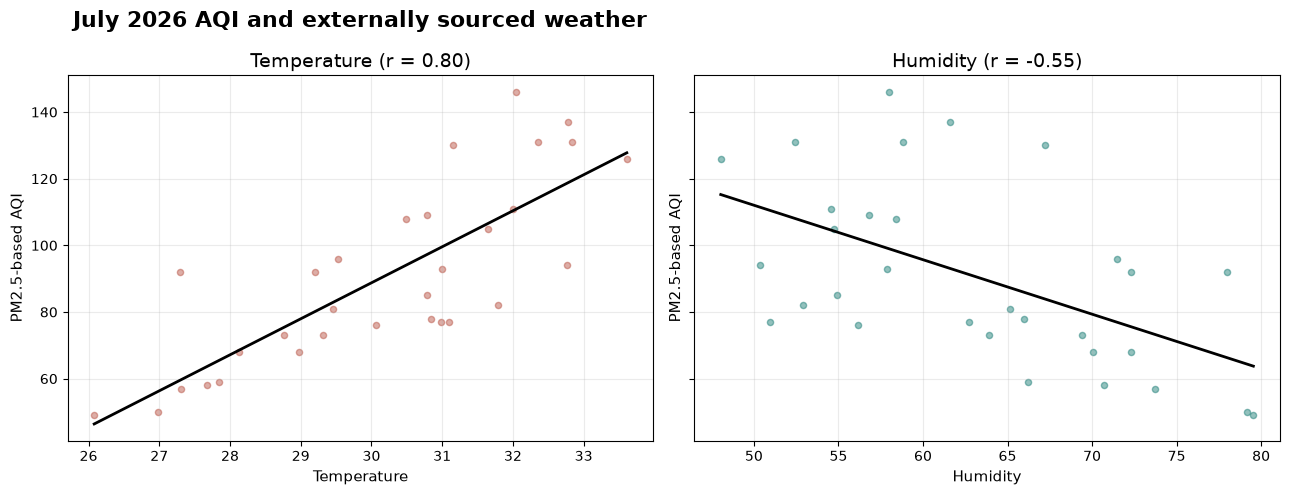

July temperature correlation: 0.797
July humidity correlation: -0.547


In [124]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
july_r_temp = scatter_with_trend(
    axes[0], july_2026_merged, "Temperature", "PM2.5_AQI", "#B54A3A"
)
july_r_humidity = scatter_with_trend(
    axes[1], july_2026_merged, "Humidity", "PM2.5_AQI", "#0F766E"
)
fig.suptitle(
    "July 2026 AQI and externally sourced weather",
    fontsize=16, fontweight="bold", x=0.06, ha="left",
)
fig.tight_layout()
plt.show()
print(f"July temperature correlation: {july_r_temp:.3f}")
print(f"July humidity correlation: {july_r_humidity:.3f}")

# Part E: Interpretation and limitations

## 31. What has been established

- The PDFs do not expose data in the same way.
- Text extraction may fail on a scanned document.
- Table extraction may still lose units or row meaning.
- The supplied CSVs can be loaded into a common structure.
- Pollutant behaviour can be explored through time, season, distribution, and relationships.

## What has not been established

- that every CSV value exactly matches its PDF;
- that monitoring coverage represents all of Islamabad;
- that missing reports or dates are random;
- that concentration values have already been converted to AQI;
- that associations are causal; or
- that these files alone support a trustworthy public advisory.

In [125]:
limitations = [
    "Source PDFs use multiple structures and extraction methods.",
    "Working CSV rows require comparison with source pages.",
    "Monitoring location and representativeness need documentation.",
    "Pollutant concentration is not a calculated AQI.",
    "Plots describe available observations; they do not prove causation.",
]

for number, limitation in enumerate(limitations, start=1):
    print(f"{number}. {limitation}")

1. Source PDFs use multiple structures and extraction methods.
2. Working CSV rows require comparison with source pages.
3. Monitoring location and representativeness need documentation.
4. Pollutant concentration is not a calculated AQI.
5. Plots describe available observations; they do not prove causation.


## 32. Exit reflection

1. Why did the first tool fail for at least one PDF?
2. What new capability did the second tool provide?
3. When is OCR appropriate, and why must it be checked?
4. What is the difference between changing data and changing styling?
5. Which plot would you use for an exploratory question, and why?
6. What additional evidence is needed before a public advisory?

```text
Inventory
   ↓
Try a suitable tool
   ↓
Observe and record failure
   ↓
Change the tool
   ↓
Validate against the source
   ↓
Use working data
   ↓
Plot from simple to complex
   ↓
Interpret with limitations
```